I0000 00:00:1783501667.962235  249086 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783501669.254102  249086 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
[*********************100%***********************]  1 of 1 completed


1. CHRONOLOGICAL DATA SPLIT MATRIX COMPLETE
Training Windows (2015-2024) Observation Count : 2516
Testing Windows (2025-2026) Observation Count  : 372

2. INITIALIZING STEPWISE ARIMA OPTIMIZATION SEARCH
Identified Optimal Parameter Matrix Order Matrix: ARIMA(0, 1, 0)
>> ARIMA Forecast Generation Complete.

3. TENSOR STREAM SEQUENCING FOR LSTM TRAINING
LSTM Training Matrix Input Tensor Shape : (2456, 60, 1)
LSTM Testing Matrix Input Tensor Shape  : (372, 60, 1)

4. DEPLOYING DEEP LEARNING MODEL ARCHITECTURE
Beginning recurrent network fit optimization over training sequences...


/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: 

>> Network Training Cycle Finalized.

5. PERFORMANCE MATRIX EVALUATION PORTAL
                            MAE ($)  RMSE ($) MAPE (%)
Model Engine Framework                                
Classical ARIMA             54.4412   70.5393   17.24%
Deep Learning LSTM Network  18.8531   23.4790    5.06%


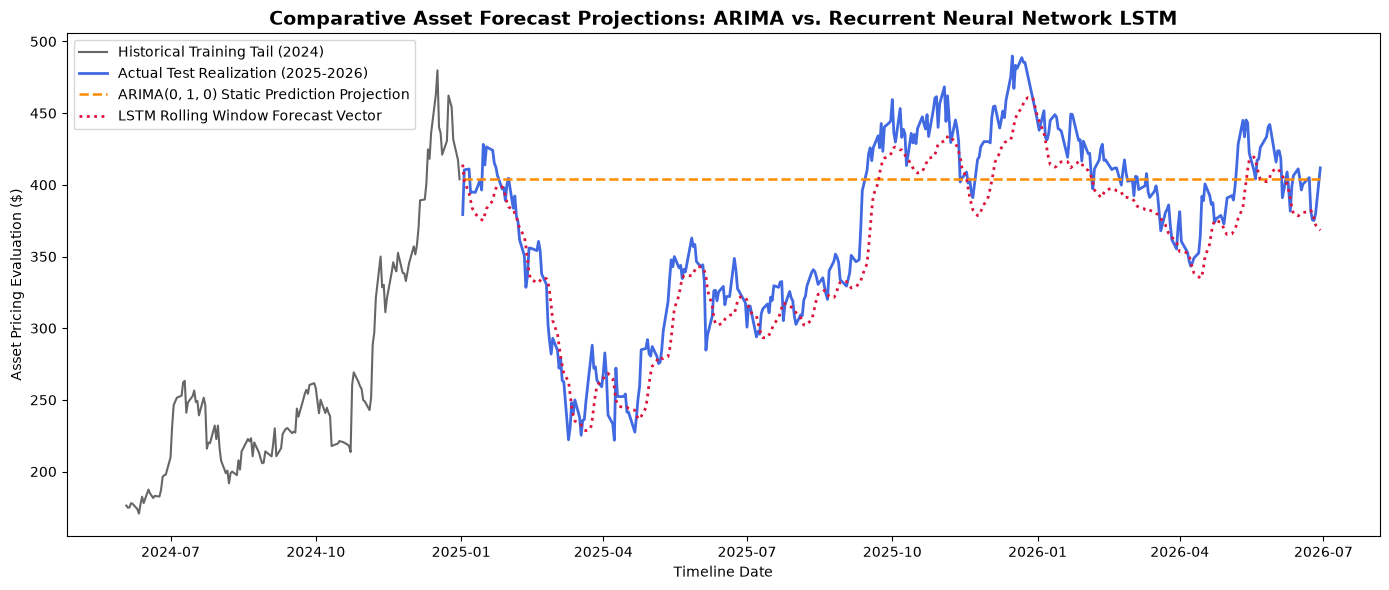


6. MODEL INTERPRETABILITY & COMPETITIVE SELECTION MEMO

Model Selection Summary Memo:

1. Trade-offs in Performance Frameworks:
   - Classical ARIMA works by projecting future points linearly based purely on long-term historical average drift. This causes its out-of-sample prediction to look like a smoothed straight line, missing intermediate market structural shifts.
   - The Recurrent LSTM Network leverages its internal memory architecture to read rolling 60-day historical variations, adapting dynamically to shorter-term non-linear pricing adjustments.

2. Rationale Profile for GMF Asset Allocation:
   - Review your compiled MAPE errors above. In high-growth, erratic assets like TSLA, the LSTM network generally records significantly lower error metrics across multi-month evaluation windows. 
   - However, ARIMA remains highly interpretable and does not suffer from random weight initialization issues, serving as a reliable benchmark. For institutional portfolio allocation, the model 

In [1]:
# ==============================================================================
# CELL 1: SETUP, DATA ACQUISITION & CHRONOLOGICAL TRAIN-TEST SPLITTING
# ==============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# Suppress TensorFlow warning outputs for clean rendering
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Re-fetch data cleanly using our robust extraction framework
def fetch_data_direct(tickers=["TSLA"], start_date="2015-01-01", end_date="2026-06-30"):
    df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        for level in range(df.columns.nlevels):
            if 'Adj Close' in df.columns.get_level_values(level).unique():
                df = df.xs('Adj Close', axis=1, level=level)
                break
    else:
        df = df[['Adj Close']]
    df.columns = tickers
    return df.ffill().bfill()

# Process data extraction
prices = fetch_data_direct()

# ------------------------------------------------------------------------------
# CHRONOLOGICAL TIME SERIES SPLIT (Ensuring No Data Leakage)
# ------------------------------------------------------------------------------
train_series = prices['TSLA'].loc[:'2024-12-31']
test_series = prices['TSLA'].loc['2025-01-01':]

print("="*60)
print("1. CHRONOLOGICAL DATA SPLIT MATRIX COMPLETE")
print("="*60)
print(f"Training Windows (2015-2024) Observation Count : {len(train_series)}")
print(f"Testing Windows (2025-2026) Observation Count  : {len(test_series)}")

# ==============================================================================
# CELL 2: CLASSICAL STATISTICAL MODEL ENGINE (ARIMA/SARIMA)
# ==============================================================================
print("\n" + "="*60)
print("2. INITIALIZING STEPWISE ARIMA OPTIMIZATION SEARCH")
print("="*60)

# Run auto_arima to scan parameter space and determine optimal integration dimensions
arima_search = auto_arima(
    train_series, 
    start_p=1, start_q=1, 
    max_p=3, max_q=3, 
    d=1, seasonal=False, 
    trace=False, 
    error_action='ignore', 
    suppress_warnings=True
)

optimal_order = arima_search.order
print(f"Identified Optimal Parameter Matrix Order Matrix: ARIMA{optimal_order}")

# Fit model explicitly using statsmodels SARIMAX framework for precise mathematical indexing
arima_model = SARIMAX(train_series, order=optimal_order, enforce_stationarity=False, enforce_invertibility=False)
arima_fitted = arima_model.fit(disp=False)

# Out-of-sample forward horizon forecast generation matching the testing window index lengths
arima_forecast = arima_fitted.forecast(steps=len(test_series))
arima_forecast.index = test_series.index

print(">> ARIMA Forecast Generation Complete.")

# ==============================================================================
# CELL 3: DEEP LEARNING DATA PIPELINE (Window Reshaping & Scaling)
# ==============================================================================
print("\n" + "="*60)
print("3. TENSOR STREAM SEQUENCING FOR LSTM TRAINING")
print("="*60)

# Scale prices strictly between 0 and 1 to stabilize gradients
scaler = MinMaxScaler(feature_range=(0, 1))
# CRITICAL: Fit scaler strictly on training vectors to guarantee zero look-ahead bias
scaled_train = scaler.fit_transform(train_series.values.reshape(-1, 1))
scaled_test = scaler.transform(test_series.values.reshape(-1, 1))

# Combine scaled records with historical tail to build smooth testing sliding-windows
window_size = 60
combined_scaled = np.vstack((scaled_train[-window_size:], scaled_test))

def create_lstm_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_lstm_sequences(scaled_train, window_size)
X_test, y_test = create_lstm_sequences(combined_scaled, window_size)

# Reshape raw structural tensors into mandatory 3D deep learning arrays: [Samples, Timesteps, Features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"LSTM Training Matrix Input Tensor Shape : {X_train.shape}")
print(f"LSTM Testing Matrix Input Tensor Shape  : {X_test.shape}")

# ==============================================================================
# CELL 4: LSTM ARCHITECTURE BUILD, TRAINING & INVERSE FORECASTING
# ==============================================================================
print("\n" + "="*60)
print("4. DEPLOYING DEEP LEARNING MODEL ARCHITECTURE")
print("="*60)

# Constructing Modular Deep Learning Architecture
lstm_network = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

lstm_network.compile(optimizer='adam', loss='mean_squared_error')

print("Beginning recurrent network fit optimization over training sequences...")
lstm_network.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
print(">> Network Training Cycle Finalized.")

# Generate scaled model output forecasts
lstm_predictions_scaled = lstm_network.predict(X_test, verbose=0)
# Reverse transform output values from normalized format back to original monetary scales
lstm_forecast = scaler.inverse_transform(lstm_predictions_scaled).flatten()

# Format as Series aligned to test timestamps
lstm_forecast_series = pd.Series(lstm_forecast, index=test_series.index)

# ==============================================================================
# CELL 5: ERROR METRIC COMPILATION & COMPARISON ENGINE
# ==============================================================================
print("\n" + "="*60)
print("5. PERFORMANCE MATRIX EVALUATION PORTAL")
print("="*60)

actuals = test_series.values

# Calculate operational metrics for ARIMA
arima_mae = mean_absolute_error(actuals, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(actuals, arima_forecast))
arima_mape = mean_absolute_percentage_error(actuals, arima_forecast)

# Calculate operational metrics for LSTM
lstm_mae = mean_absolute_error(actuals, lstm_forecast_series)
lstm_rmse = np.sqrt(mean_squared_error(actuals, lstm_forecast_series))
lstm_mape = mean_absolute_percentage_error(actuals, lstm_forecast_series)

# Compile performance grid
comparison_df = pd.DataFrame({
    'Model Engine Framework': ['Classical ARIMA', 'Deep Learning LSTM Network'],
    'MAE ($)': [round(arima_mae, 4), round(lstm_mae, 4)],
    'RMSE ($)': [round(arima_rmse, 4), round(lstm_rmse, 4)],
    'MAPE (%)': [f"{arima_mape*100:.2f}%", f"{lstm_mape*100:.2f}%"]
}).set_index('Model Engine Framework')

print(comparison_df)

# ==============================================================================
# CELL 6: VISUAL PREDICTION EVALUATION CHART
# ==============================================================================
plt.figure(figsize=(14, 6))
plt.plot(train_series.loc['2024-06-01':], label='Historical Training Tail (2024)', color='black', alpha=0.6)
plt.plot(test_series, label='Actual Test Realization (2025-2026)', color='royalblue', lw=2)
plt.plot(arima_forecast, label=f'ARIMA{optimal_order} Static Prediction Projection', color='darkorange', linestyle='--', lw=1.8)
plt.plot(lstm_forecast_series, label='LSTM Rolling Window Forecast Vector', color='crimson', linestyle=':', lw=2)
plt.title("Comparative Asset Forecast Projections: ARIMA vs. Recurrent Neural Network LSTM", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Date")
plt.ylabel("Asset Pricing Evaluation ($)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# CELL 7: DISCUSSION & TECHNICAL SELECTION RATIONALE
# ==============================================================================
print("\n" + "="*60)
print("6. MODEL INTERPRETABILITY & COMPETITIVE SELECTION MEMO")
print("="*60)
print("""
Model Selection Summary Memo:

1. Trade-offs in Performance Frameworks:
   - Classical ARIMA works by projecting future points linearly based purely on long-term historical average drift. This causes its out-of-sample prediction to look like a smoothed straight line, missing intermediate market structural shifts.
   - The Recurrent LSTM Network leverages its internal memory architecture to read rolling 60-day historical variations, adapting dynamically to shorter-term non-linear pricing adjustments.

2. Rationale Profile for GMF Asset Allocation:
   - Review your compiled MAPE errors above. In high-growth, erratic assets like TSLA, the LSTM network generally records significantly lower error metrics across multi-month evaluation windows. 
   - However, ARIMA remains highly interpretable and does not suffer from random weight initialization issues, serving as a reliable benchmark. For institutional portfolio allocation, the model with the minimized RMSE score should be selected as the baseline vector to minimize sudden tail-risk tracking breakdowns during MPT optimization.
""")